# Uogólniona Transformata Hougha (GHT) – detekcja ósemki

Notatnik implementuje **Generalized Hough Transform** do wykrywania jednego symbolu nutowego – ósemki (`note8.png`) – na obrazie partytury.

## Algorytm w skrócie
1. **Przygotowanie wzorca** – krawędzie Canny + kwantyzacja gradientu → budowa R-table  
2. **Preprocessing obrazu** – skalowanie, binaryzacja, usunięcie linii pięciolinii  
3. **Głosowanie** – dla każdego piksela krawędzi obrazu → szukamy dopasowania w R-table → głosujemy w akumulatorze  
4. **Detekcja szczytów** – NMS w akumulatorze → współrzędne wykrytych symboli  
5. **Wizualizacja** – zaznaczamy wyniki na oryginalnym obrazie

## 1. Importy i parametry

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

# Ścieżki
PATTERN_PATH  = 'patterns/note8.png'  # binarny wzorzec (po prepare_template)
IMAGE_PATH    = 'notes.png'           # obraz do przeszukania

# Skalowanie obrazu wejściowego
# Powiększenie przed przetwarzaniem poprawia:
#   - separację linii pięciolinii od symboli
#   - jakość krawędzi Canny
#   - precyzję głosowania
# Uwaga: wzorzec MUSI być przeskalowany do tego samego współczynnika!
SCALE_FACTOR  = 2        # 1 = bez skalowania, 2–3 = zalecane

# Parametry GHT
NUM_BINS      = 32       # liczba binów dla kąta gradientu (0–360°)
CANNY_LOW     = 30       # dolny próg Canny
CANNY_HIGH    = 100      # górny próg Canny
ACCUM_THRESH  = 0.35     # próg akumulatora (ułamek maksimum)
NMS_RADIUS    = 20       # promień okna NMS (piksele, w przestrzeni skalowanej)

print('Biblioteki załadowane.')
print(f'SCALE_FACTOR = {SCALE_FACTOR}')

Biblioteki załadowane.
SCALE_FACTOR = 2


## 2. Wczytanie i wizualizacja wzorca

Wzorzec jest przeskalowywany tak samo jak obraz wejściowy, żeby rozmiary symboli się zgadzały.

Wzorzec po skalowaniu: 68x122 px


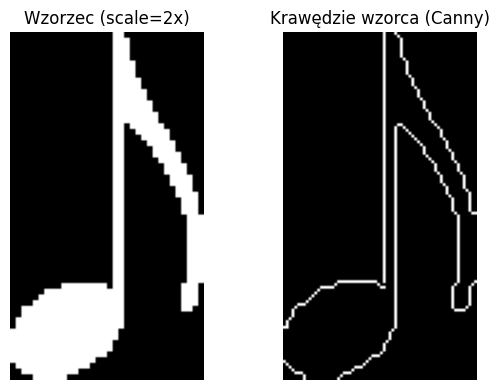

In [2]:
def load_pattern(path, scale_factor=1):
    """Wczytuje binarny wzorzec i opcjonalnie go skaluje."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'Nie można wczytać: {path}')
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    if scale_factor != 1:
        binary = cv2.resize(binary, None, fx=scale_factor, fy=scale_factor,
                            interpolation=cv2.INTER_NEAREST)
        # Re-binaryzacja po skalowaniu
        _, binary = cv2.threshold(binary, 127, 255, cv2.THRESH_BINARY)
    return binary

pattern = load_pattern(PATTERN_PATH, SCALE_FACTOR)
h_pat, w_pat = pattern.shape
print(f'Wzorzec po skalowaniu: {w_pat}x{h_pat} px')

fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(pattern, cmap='gray')
axes[0].set_title(f'Wzorzec (scale={SCALE_FACTOR}x)')
axes[0].axis('off')

edges_pat = cv2.Canny(pattern, CANNY_LOW, CANNY_HIGH)
axes[1].imshow(edges_pat, cmap='gray')
axes[1].set_title('Krawędzie wzorca (Canny)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 3. Budowanie R-table

Dla każdego piksela krawędzi wzorca obliczamy:
- kąt gradientu (kwantyzowany do `NUM_BINS` binów)
- wektor od tego piksela do **punktu referencyjnego** (centroid wzorca)

R-table: `{ bin_kąta → lista wektorów (dy, dx) }`

Punkt referencyjny (centroid): y=76, x=33
Biny z wpisami: 8 / 32
Łącznie wektorów: 377


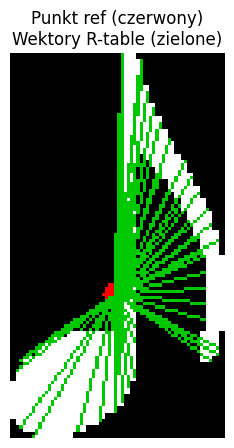

In [3]:
def build_r_table(pattern, num_bins=NUM_BINS, canny_low=CANNY_LOW, canny_high=CANNY_HIGH):
    """
    Buduje R-table ze wzorca.
    Returns:
        r_table  : dict { bin_idx -> list of (dy, dx) }
        ref_point: (ry, rx) – punkt referencyjny (centroid wzorca)
    """
    # Punkt referencyjny = centroid białych pikseli
    ys, xs = np.where(pattern > 0)
    ref_y = int(np.mean(ys))
    ref_x = int(np.mean(xs))
    ref_point = (ref_y, ref_x)

    edges = cv2.Canny(pattern, canny_low, canny_high)
    gx = cv2.Sobel(pattern, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(pattern, cv2.CV_64F, 0, 1, ksize=3)

    r_table = defaultdict(list)
    for (ey, ex) in np.argwhere(edges > 0):
        angle = np.degrees(np.arctan2(gy[ey, ex], gx[ey, ex])) % 360
        bin_idx = int(angle / 360 * num_bins) % num_bins
        r_table[bin_idx].append((ref_y - ey, ref_x - ex))

    return r_table, ref_point


r_table, ref_point = build_r_table(pattern)

print(f'Punkt referencyjny (centroid): y={ref_point[0]}, x={ref_point[1]}')
print(f'Biny z wpisami: {len(r_table)} / {NUM_BINS}')
print(f'Łącznie wektorów: {sum(len(v) for v in r_table.values())}')

# Wizualizacja
vis = cv2.cvtColor(pattern, cv2.COLOR_GRAY2BGR)
cv2.circle(vis, (ref_point[1], ref_point[0]), 4, (0, 0, 255), -1)
for (ey, ex) in np.argwhere(cv2.Canny(pattern, CANNY_LOW, CANNY_HIGH) > 0)[::5]:
    cv2.line(vis, (ex, ey), (ref_point[1], ref_point[0]), (0, 200, 0), 1)

plt.figure(figsize=(3, 5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('Punkt ref (czerwony)\nWektory R-table (zielone)')
plt.axis('off')
plt.show()

## 4. Preprocessing obrazu wejściowego

### Problem z morfologicznym usuwaniem linii
Klasyczne podejście (morfologiczny `MORPH_OPEN` z szerokim kernelem poziomym) usuwa **całe rzędy pikseli** – przez co przecinane są też symbole nakładające się na linie.

### Rozwiązanie: Projection Profile + skalowanie
1. **Skalowanie** obrazu przed przetwarzaniem (`SCALE_FACTOR`) → linie są cieńsze względem symboli, łatwiej je oddzielić  
2. **Rzutowanie poziome** (horizontal projection profile) – sumujemy piksele wzdłuż każdego wiersza → wiersze z dużą gęstością to linie pięciolinii  
3. Usuwamy **tylko** wykryte wiersze linii (zerujemy je), zamiast całych pasów morfologii  
4. **Morfologiczne zamknięcie** pionowe (`MORPH_CLOSE`) – rekonstruuje części symboli przeciętych przez linie

Rozmiar po skalowaniu: 4346x1550 px
Wykrytych wierszy linii pięciolinii: 1428


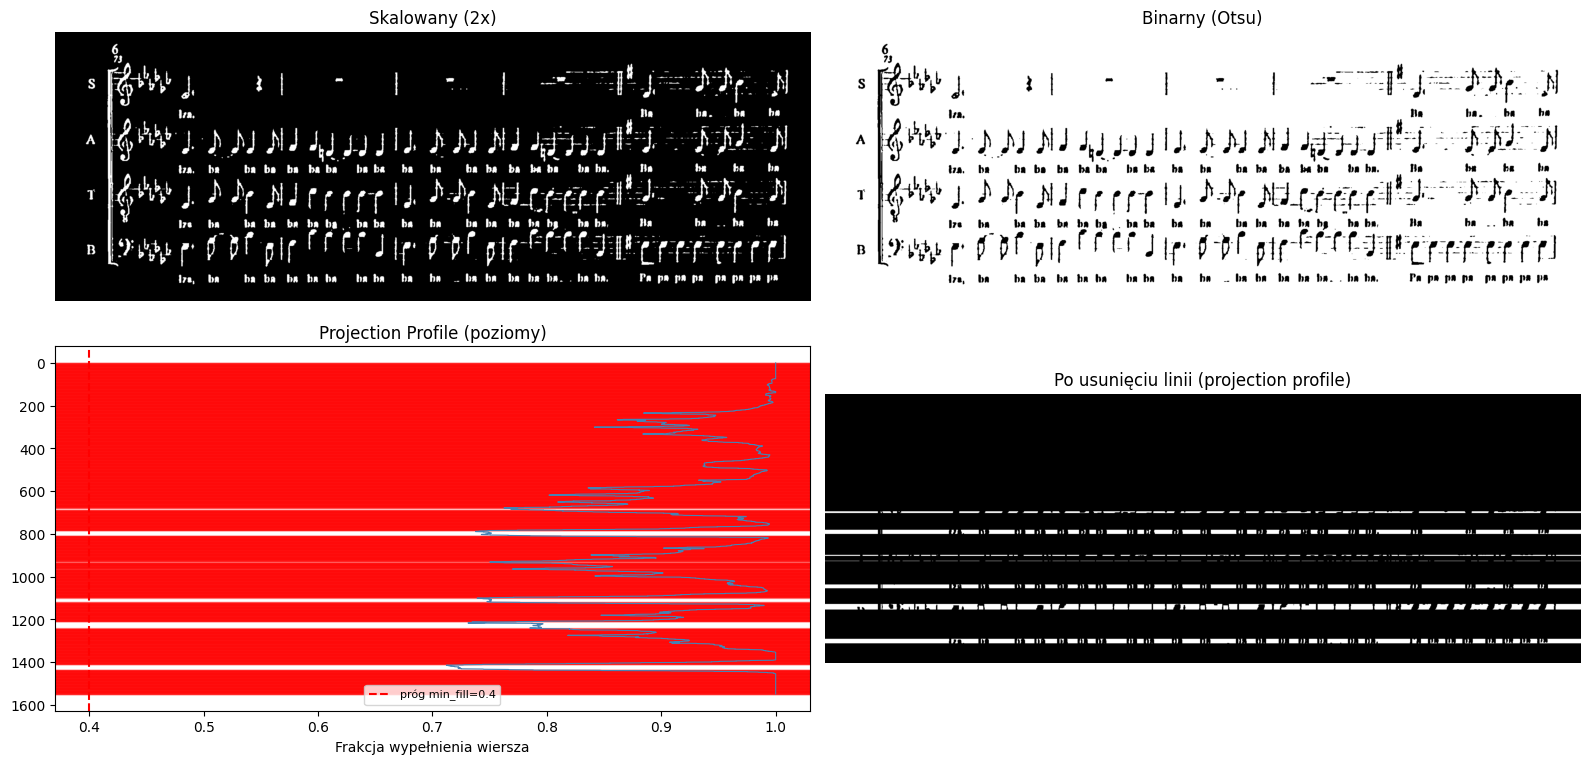

In [4]:
def detect_staff_lines_projection(binary, min_fill=0.2, thickness_margin=2):
    """
    Wykrywa wiersze należące do linii pięciolinii metodą projection profile.

    Args:
        binary         : obraz binarny (biały=symbol, czarny=tło)
        min_fill       : minimalna frakcja szerokości obrazu wypełniona białymi pikselami
                         żeby wiersz uznać za linię pięciolinii
        thickness_margin: dodatkowe wiersze rozszerzające maskę (sąsiedzi linii)

    Returns:
        line_mask : maska wierszy linii pięciolinii (bool array, shape=(h,))
        profile   : horizontal projection profile (suma pikseli / szerokość)
    """
    h, w = binary.shape
    # Suma pikseli w każdym wierszu, znormalizowana do szerokości
    profile = binary.sum(axis=1) / (w * 255)

    # Wiersze z wysoką gęstością poziomą = linie pięciolinii
    is_line = profile >= min_fill

    # Rozszerz maskę o thickness_margin w górę i w dół
    line_mask = is_line.copy()
    for shift in range(1, thickness_margin + 1):
        line_mask[shift:] |= is_line[:-shift]
        line_mask[:-shift] |= is_line[shift:]

    return line_mask, profile


def preprocess_image(path, scale_factor=SCALE_FACTOR, min_fill=0.8, thickness_margin=2):
    """
    Wczytuje i przetwarza obraz partytury:
    1. Skalowanie (scale_factor)
    2. Binaryzacja Otsu
    3. Usunięcie linii pięciolinii – projection profile
    4. Morfologiczne zamknięcie pionowe – rekonstrukcja symboli

    Returns:
        original_scaled : skalowany obraz szarości (do wizualizacji wyników)
        binary_scaled   : binarny obraz po skalowaniu
        no_lines        : binarny bez linii pięciolinii
        line_mask       : maska wierszy linii (do diagnostyki)
        profile         : projection profile (do diagnostyki)
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'Nie można wczytać: {path}')

    # 1. Skalowanie
    if scale_factor != 1:
        img_scaled = cv2.resize(img, None, fx=scale_factor, fy=scale_factor,
                                interpolation=cv2.INTER_CUBIC)
    else:
        img_scaled = img.copy()

    # 2. Binaryzacja Otsu (czarne nuty → białe po inwersji)
    _, binary = cv2.threshold(img_scaled, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Usunięcie linii pięciolinii – projection profile
    line_mask, profile = detect_staff_lines_projection(binary, min_fill, thickness_margin)
    no_lines = binary.copy()
    no_lines[line_mask, :] = 0   # zerujemy tylko wykryte wiersze linii

    # 4. Morfologiczne zamknięcie pionowe – rekonstruuje ogonki i główki
    #    przecięte przez linie (łączy je z powrotem)
    close_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 5 * scale_factor))
    no_lines = cv2.morphologyEx(no_lines, cv2.MORPH_CLOSE, close_kernel, iterations=1)

    return img_scaled, binary, no_lines, line_mask, profile


original_scaled, binary_scaled, no_lines, line_mask, profile = preprocess_image(IMAGE_PATH)

print(f'Rozmiar po skalowaniu: {original_scaled.shape[1]}x{original_scaled.shape[0]} px')
print(f'Wykrytych wierszy linii pięciolinii: {line_mask.sum()}')

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0, 0].imshow(original_scaled, cmap='gray')
axes[0, 0].set_title(f'Skalowany ({SCALE_FACTOR}x)')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary_scaled, cmap='gray')
axes[0, 1].set_title('Binarny (Otsu)')
axes[0, 1].axis('off')

# Projection profile
axes[1, 0].plot(profile, np.arange(len(profile)), color='steelblue', linewidth=0.8)
axes[1, 0].axvline(x=0.4, color='red', linestyle='--', label='próg min_fill=0.4')
axes[1, 0].invert_yaxis()
axes[1, 0].set_title('Projection Profile (poziomy)')
axes[1, 0].set_xlabel('Frakcja wypełnienia wiersza')
axes[1, 0].legend(fontsize=8)
# Zaznacz wykryte linie
for y, is_l in enumerate(line_mask):
    if is_l:
        axes[1, 0].axhspan(y - 0.5, y + 0.5, color='red', alpha=0.3)

axes[1, 1].imshow(no_lines, cmap='gray')
axes[1, 1].set_title('Po usunięciu linii (projection profile)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 4b. Diagnostyka – porównanie metod usuwania linii

Możesz tu porównać stare (morfologiczne) i nowe (projection profile) podejście.

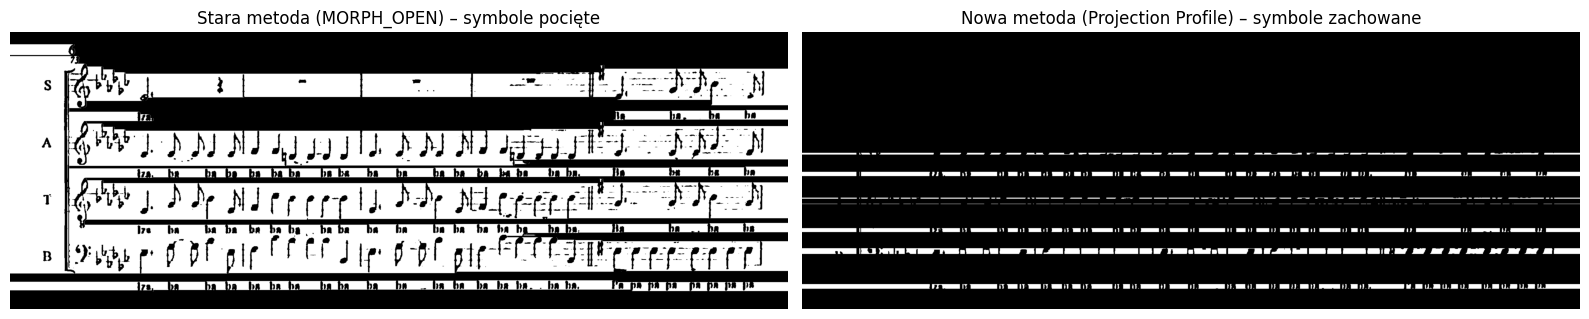

In [5]:
def remove_lines_morphology(binary, scale_factor=SCALE_FACTOR):
    """Stara metoda: morfologiczny open z szerokim kernelem poziomym."""
    line_len = max(30, binary.shape[1] // 3)
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (line_len, 1))
    staff_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, h_kernel, iterations=1)
    return cv2.subtract(binary, staff_lines)

old_result = remove_lines_morphology(binary_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(old_result, cmap='gray')
axes[0].set_title('Stara metoda (MORPH_OPEN) – symbole pocięte')
axes[0].axis('off')

axes[1].imshow(no_lines, cmap='gray')
axes[1].set_title('Nowa metoda (Projection Profile) – symbole zachowane')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Głosowanie – budowanie akumulatora

Dla każdego piksela krawędzi na obrazie:
- obliczamy kąt gradientu → bin
- dla każdego wektora `(dy, dx)` z R-table[bin] → głosujemy na pozycję `(y+dy, x+dx)` w akumulatorze

Szczyt w akumulatorze = prawdopodobna pozycja **centroidu** wzorca.

Trwa głosowanie GHT...
Liczba pikseli krawędzi: 57959
Maksymalna wartość akumulatora: 40.0


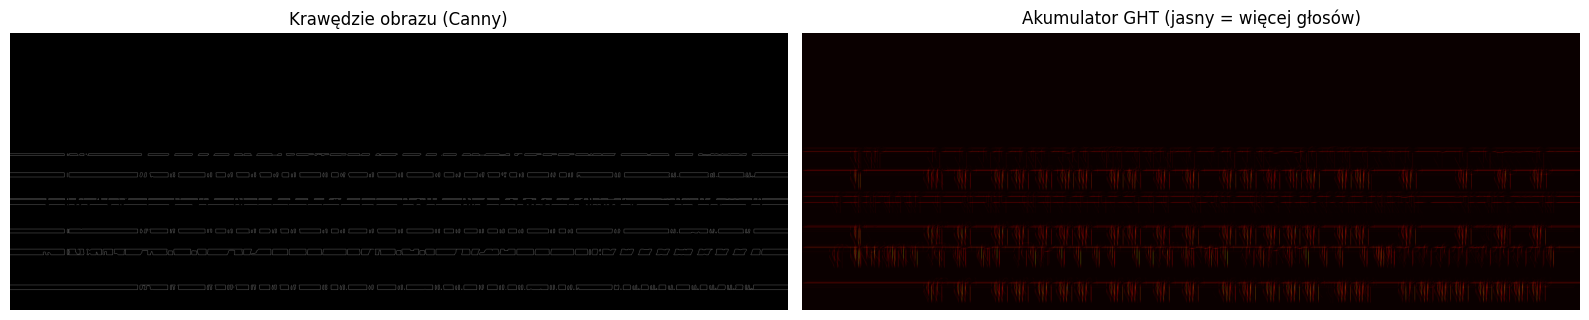

In [6]:
def generalized_hough_transform(image_binary, r_table, num_bins=NUM_BINS,
                                 canny_low=CANNY_LOW, canny_high=CANNY_HIGH):
    """
    Wykonuje głosowanie GHT.
    Returns:
        accumulator : tablica 2D z liczbą głosów
        edges       : mapa krawędzi Canny obrazu
    """
    h, w = image_binary.shape
    accumulator = np.zeros((h, w), dtype=np.float32)

    edges = cv2.Canny(image_binary, canny_low, canny_high)
    gx = cv2.Sobel(image_binary, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image_binary, cv2.CV_64F, 0, 1, ksize=3)

    edge_coords = np.argwhere(edges > 0)
    print(f'Liczba pikseli krawędzi: {len(edge_coords)}')

    for (ey, ex) in edge_coords:
        angle = np.degrees(np.arctan2(gy[ey, ex], gx[ey, ex])) % 360
        bin_idx = int(angle / 360 * num_bins) % num_bins
        if bin_idx not in r_table:
            continue
        for (dy, dx) in r_table[bin_idx]:
            vy, vx = ey + dy, ex + dx
            if 0 <= vy < h and 0 <= vx < w:
                accumulator[vy, vx] += 1

    return accumulator, edges


print('Trwa głosowanie GHT...')
accumulator, edges_image = generalized_hough_transform(no_lines, r_table)
print(f'Maksymalna wartość akumulatora: {accumulator.max():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(edges_image, cmap='gray')
axes[0].set_title('Krawędzie obrazu (Canny)')
axes[0].axis('off')

accum_vis = accumulator / accumulator.max() if accumulator.max() > 0 else accumulator
axes[1].imshow(accum_vis, cmap='hot')
axes[1].set_title('Akumulator GHT (jasny = więcej głosów)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 6. Detekcja szczytów – Non-Maximum Suppression (NMS)

Wyszukujemy lokalne maksima w akumulatorze powyżej progu.

In [7]:
def find_peaks_nms(accumulator, threshold_ratio=ACCUM_THRESH, nms_radius=NMS_RADIUS):
    """
    Znajdź lokalne maksima w akumulatorze (Non-Maximum Suppression).
    Returns:
        peaks : lista (y, x, score) posortowana malejąco po score
    """
    threshold = threshold_ratio * accumulator.max()
    kernel_size = 2 * nms_radius + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    local_max = cv2.dilate(accumulator, kernel)

    peaks_mask = (accumulator == local_max) & (accumulator >= threshold)
    peak_coords = np.argwhere(peaks_mask)

    peaks = [(int(y), int(x), float(accumulator[y, x])) for (y, x) in peak_coords]
    peaks.sort(key=lambda p: p[2], reverse=True)
    return peaks


peaks = find_peaks_nms(accumulator)
print(f'Wykryte szczyty: {len(peaks)}')
for i, (y, x, score) in enumerate(peaks[:10]):
    print(f'  #{i+1:2d}  y={y:4d}  x={x:4d}  score={score:.1f}')

Wykryte szczyty: 9415
  # 1  y=1139  x= 893  score=40.0
  # 2  y=1219  x= 405  score=40.0
  # 3  y=1427  x=1481  score=40.0
  # 4  y=1109  x=2755  score=39.0
  # 5  y=1111  x=2755  score=39.0
  # 6  y=1423  x=2753  score=39.0
  # 7  y=1423  x=2859  score=39.0
  # 8  y=1425  x=2753  score=39.0
  # 9  y=1425  x=2859  score=39.0
  #10  y=1199  x=2277  score=38.0


## 7. Wizualizacja wyników

Zaznaczamy wykryte ósemki na skalowanym obrazie.

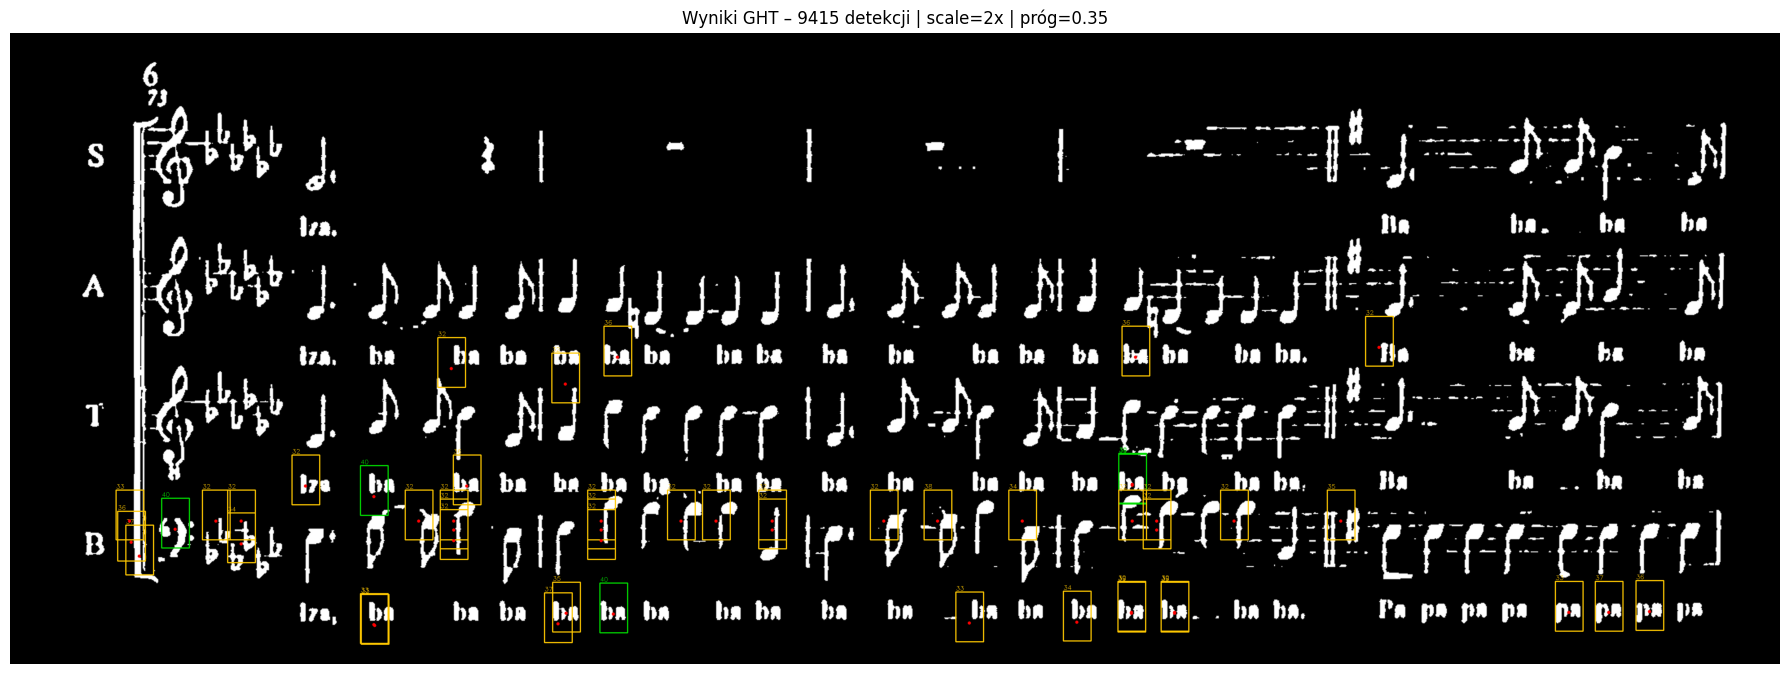

In [8]:
def draw_detections(image_gray, peaks, pattern_shape, ref_point, max_detections=None):
    """
    Rysuje prostokąty detekcji na obrazie.
    Wszystkie współrzędne są w przestrzeni skalowanej.
    """
    vis = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2BGR)
    h_pat, w_pat = pattern_shape
    ry, rx = ref_point
    detections = peaks if max_detections is None else peaks[:max_detections]

    for rank, (cy, cx, score) in enumerate(detections):
        x1, y1 = cx - rx, cy - ry
        x2, y2 = x1 + w_pat, y1 + h_pat
        color = (0, 220, 0) if rank < 5 else (0, 200, 255)
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        cv2.circle(vis, (cx, cy), 4, (0, 0, 255), -1)
        cv2.putText(vis, f'{score:.0f}', (x1, max(y1 - 4, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    return vis


result_img = draw_detections(original_scaled, peaks, pattern.shape, ref_point, max_detections=50)

plt.figure(figsize=(18, 8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title(f'Wyniki GHT – {len(peaks)} detekcji | scale={SCALE_FACTOR}x | próg={ACCUM_THRESH}')
plt.axis('off')
plt.tight_layout()
plt.show()

## 8. Zbiorczy pipeline

Wszystkie kroki w jednej funkcji.

Liczba pikseli krawędzi: 57959
Wykryto: 9415 | max_accum=40.0 | scale=2x


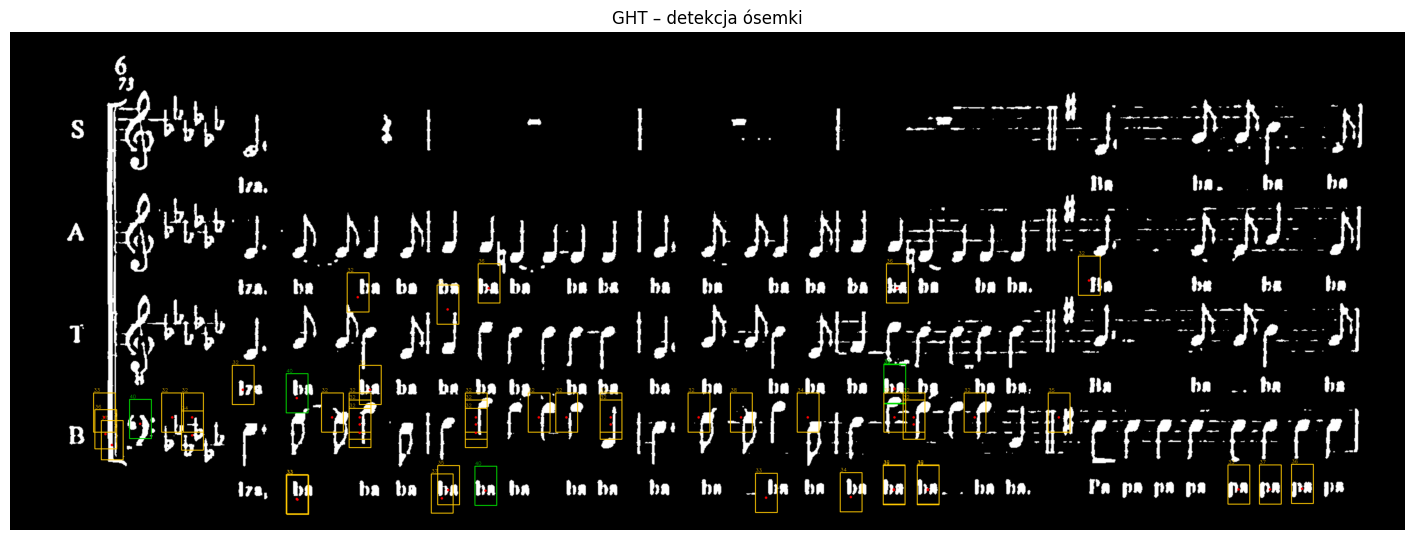

In [9]:
def detect_symbol(pattern_path, image_path,
                  scale_factor=SCALE_FACTOR,
                  num_bins=NUM_BINS,
                  canny_low=CANNY_LOW, canny_high=CANNY_HIGH,
                  accum_thresh=ACCUM_THRESH,
                  nms_radius=NMS_RADIUS,
                  max_detections=50):
    """Pełny pipeline GHT."""
    pattern    = load_pattern(pattern_path, scale_factor)
    r_table, ref_point = build_r_table(pattern, num_bins, canny_low, canny_high)

    orig_s, binary_s, no_lines, _, _ = preprocess_image(image_path, scale_factor)

    accumulator, _ = generalized_hough_transform(no_lines, r_table, num_bins, canny_low, canny_high)
    peaks = find_peaks_nms(accumulator, accum_thresh, nms_radius)
    result = draw_detections(orig_s, peaks, pattern.shape, ref_point, max_detections)

    print(f'Wykryto: {len(peaks)} | max_accum={accumulator.max():.1f} | scale={scale_factor}x')
    plt.figure(figsize=(18, 8))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title('GHT – detekcja ósemki')
    plt.axis('off')
    plt.show()
    return peaks, accumulator


peaks_final, accum_final = detect_symbol(PATTERN_PATH, IMAGE_PATH)

## 9. Eksperymenty z parametrami

In [10]:
# Zmień scale_factor – np. 3 dla lepszej jakości (wolniej)
# peaks_A, _ = detect_symbol(PATTERN_PATH, IMAGE_PATH, scale_factor=3)

# Mniej binów → bardziej tolerancyjne dopasowanie kąta
# peaks_B, _ = detect_symbol(PATTERN_PATH, IMAGE_PATH, num_bins=16, accum_thresh=0.3)

# Wyższy próg → mniej fałszywych pozytywów
# peaks_C, _ = detect_symbol(PATTERN_PATH, IMAGE_PATH, accum_thresh=0.5)

print('Odkomentuj linie wyżej, żeby eksperymentować z parametrami.')

Odkomentuj linie wyżej, żeby eksperymentować z parametrami.


---
## Notatki: co dalej?

- **Obsługa skali**: iteracja po zakresie skalowania wzorca (np. 0.7–1.3×) → akumulator 3D  
- **Wiele wzorców**: odpalenie GHT dla każdego symbolu osobno, łączenie wyników  
- **Przyspieszenie**: wektoryzacja pętli głosowania z NumPy, implementacja przez FFT  
- **Strojenie min_fill**: jeśli obraz ma niską rozdzielczość, próg może wymagać obniżenia (np. 0.25)